In [1]:
import numpy as np
import matplotlib.pyplot as plt

# check out the data

In [2]:
!ls data/

current_instrument_noise_model.dat  full_noise_model.dat
current_sgwb_noise_model.dat        instrument_noise_model.dat
data.dat                            power_data.dat
final_full_noise_model.dat          power_noise_reconstruction.dat
final_instrument_noise_model.dat    sgwb_noise_model.dat
final_sgwb_noise_model.dat          whitened_data.dat


In [3]:
power_data = np.loadtxt('data/power_data.dat')
full_noise = np.loadtxt('data/full_noise_model.dat')

In [4]:
# cols are f, CXX, CYY, CZZ, CXY, CXZ, CYZ

In [5]:
full_noise.shape

(15532, 7)

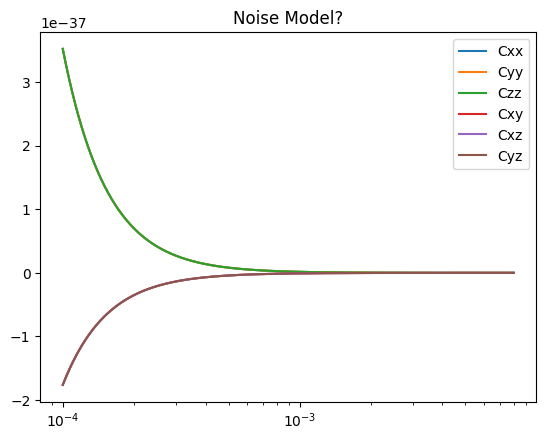

In [6]:
plt.semilogx(full_noise[:,0], full_noise[:,1], label='Cxx')
plt.semilogx(full_noise[:,0], full_noise[:,2], label='Cyy')
plt.semilogx(full_noise[:,0], full_noise[:,3], label='Czz')
plt.semilogx(full_noise[:,0], full_noise[:,4], label='Cxy')
plt.semilogx(full_noise[:,0], full_noise[:,5], label='Cxz')
plt.semilogx(full_noise[:,0], full_noise[:,6], label='Cyz')
plt.title('Noise Model?')
plt.legend()
plt.show()

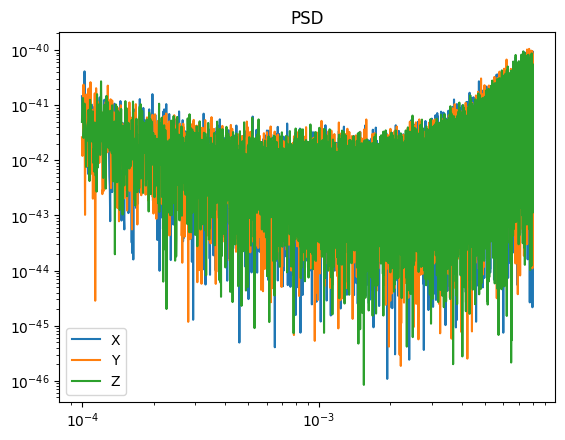

In [7]:
plt.loglog(power_data[:,0], power_data[:,1], label='X')
plt.loglog(power_data[:,0], power_data[:,2], label='Y')
plt.loglog(power_data[:,0], power_data[:,3], label='Z')
plt.title('PSD')
plt.legend()
plt.show()

# check out the chains

In [8]:
!ls chains/

log_likelihood_chain.dat  noise_chain.dat.0      temperature_chain.dat
model_chain.dat.0         parameter_chain.dat.0
noise_chain.dat           sgwb_chain.dat


In [10]:
max_rows = 2000

noise_chain = np.loadtxt('chains/noise_chain.dat',max_rows=max_rows)
#foreground_chain = np.loadtxt('chains/foreground_chain.dat',max_rows=max_rows)
sgwb_chain = np.loadtxt('chains/sgwb_chain.dat', max_rows=max_rows)
# col 0 : samples
# col 1 : logL
# rest  : params

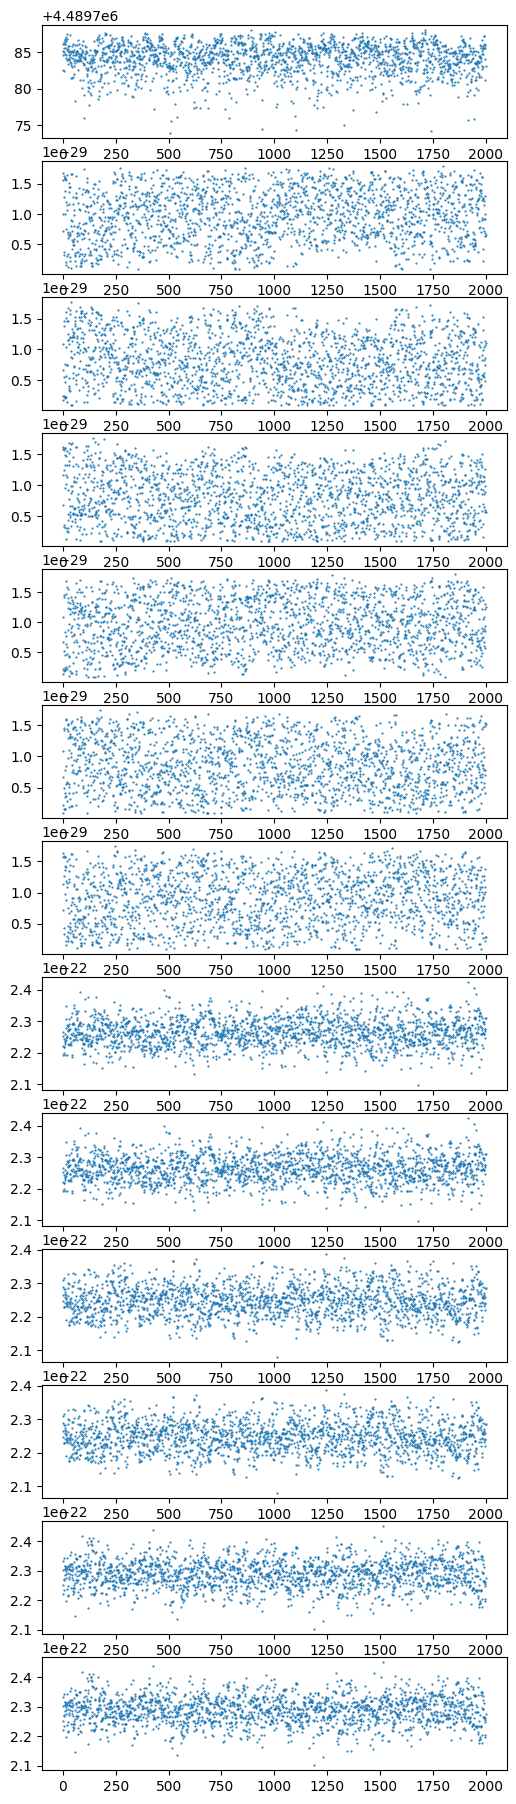

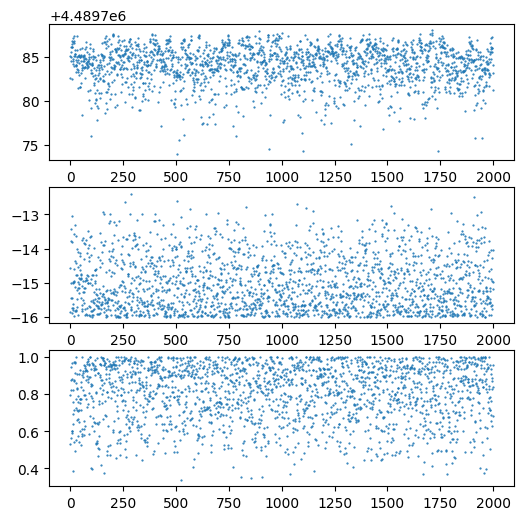

In [14]:
# trace plots
nburn = 0
fig, ax = plt.subplots(noise_chain.shape[1]-1, 1, figsize=(6,1+5/3*(noise_chain.shape[1]-1)))
for i in range(noise_chain.shape[1]-1):
    ax[i].scatter(noise_chain[nburn:,0], noise_chain[nburn:,i+1], s=0.3)
plt.show()
#fig, ax = plt.subplots(foreground_chain.shape[1]-1, 1, figsize=(6,1+5/3*(foreground_chain.shape[1]-1)))
#for i in range(foreground_chain.shape[1]-1):
#    ax[i].scatter(foreground_chain[nburn:,0], foreground_chain[nburn:,i+1], s=0.3)
#plt.show()
fig, ax = plt.subplots(sgwb_chain.shape[1]-1, 1, figsize=(6,1+5/3*(sgwb_chain.shape[1]-1)))
for i in range(sgwb_chain.shape[1]-1):
    ax[i].scatter(sgwb_chain[nburn:,0], sgwb_chain[nburn:,i+1], s=0.3)
plt.show()

In [16]:
!pip install corner

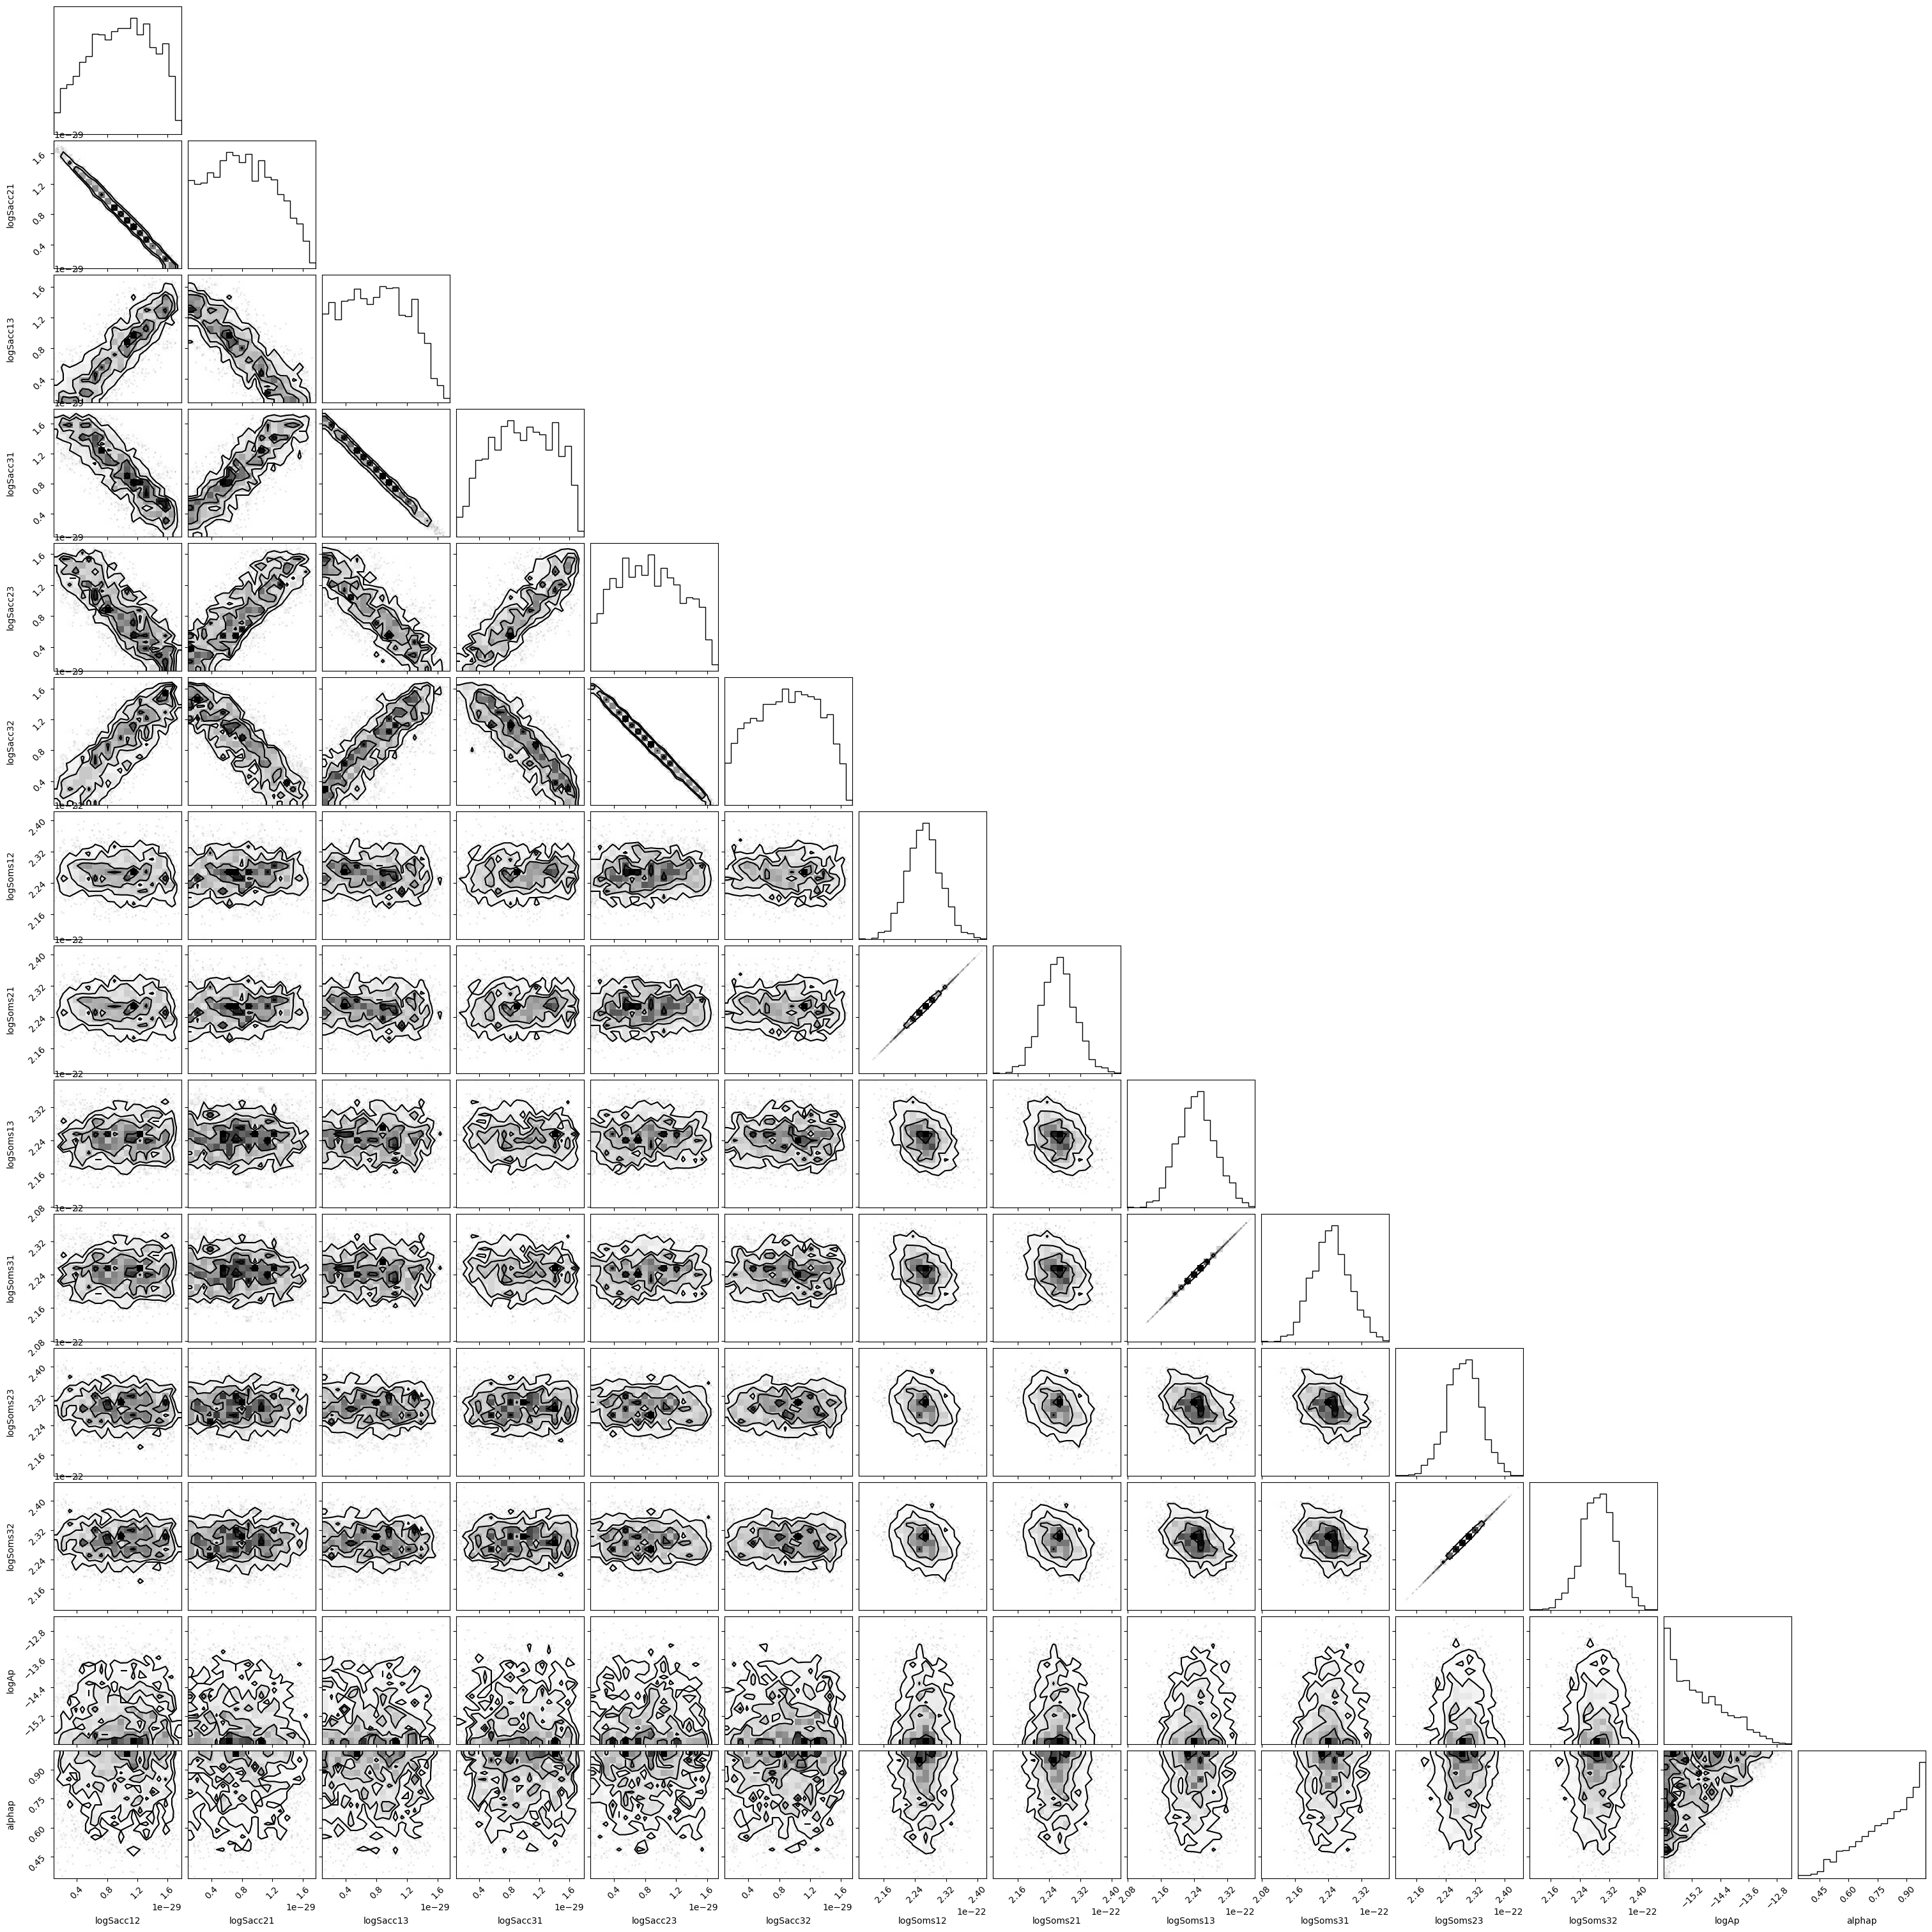

In [20]:
import corner
import pandas as pd

df = pd.DataFrame({
    'logSacc12' : noise_chain[nburn:,2],
    'logSacc21' : noise_chain[nburn:,3],
    'logSacc13' : noise_chain[nburn:,4],
    'logSacc31' : noise_chain[nburn:,5],
    'logSacc23' : noise_chain[nburn:,6],
    'logSacc32' : noise_chain[nburn:,7],
    'logSoms12' : noise_chain[nburn:,8],
    'logSoms21' : noise_chain[nburn:,9],
    'logSoms13' : noise_chain[nburn:,10],
    'logSoms31' : noise_chain[nburn:,11],
    'logSoms23' : noise_chain[nburn:,12],
    'logSoms32' : noise_chain[nburn:,13],
    #'logA'      : foreground_chain[nburn:,2],
    #'f1'        : foreground_chain[nburn:,3],
    #'alpha'     : foreground_chain[nburn:,4],
    #'fk'        : foreground_chain[nburn:,5],
    #'f2'        : foreground_chain[nburn:,6],
    'logAp'     : sgwb_chain[nburn:,2],
    'alphap'    : sgwb_chain[nburn:,3],
})
corner.corner(df, labels = df.columns)
plt.show()

In [94]:
df

,logSacc12,logSacc21,logSacc13,logSacc31,logSacc23,logSacc32,logSoms12,logSoms21,logSoms13,logSoms31,logSoms23,logSoms32
0,1.245964e-29,5.230634e-30,1.079680e-29,6.904914e-30,3.351337e-30,1.438556e-29,2.260716e-22,2.260716e-22,2.250649e-22,2.250649e-22,2.235005e-22,2.235005e-22
1,1.284332e-29,4.846962e-30,1.118048e-29,6.521242e-30,2.967665e-30,1.476923e-29,2.260716e-22,2.260716e-22,2.250649e-22,2.250649e-22,2.235005e-22,2.235005e-22
2,1.298898e-29,4.757358e-30,1.132373e-29,6.375575e-30,2.821998e-30,1.491490e-29,2.255996e-22,2.255996e-22,2.252981e-22,2.252981e-22,2.235005e-22,2.235005e-22
3,1.361881e-29,4.127528e-30,1.195356e-29,5.745745e-30,2.195980e-30,1.554473e-29,2.255996e-22,2.255996e-22,2.252981e-22,2.252981e-22,2.236477e-22,2.236477e-22
4,1.385694e-29,3.889403e-30,1.219169e-29,5.507619e-30,1.957855e-30,1.578286e-29,2.255996e-22,2.255996e-22,2.252981e-22,2.252981e-22,2.236477e-22,2.236477e-22
...,...,...,...,...,...,...,...,...,...,...,...,...
395,9.865613e-30,7.689881e-30,8.336766e-30,9.568820e-30,7.606178e-30,9.615188e-30,2.269212e-22,2.269212e-22,2.240877e-22,2.240877e-22,2.257705e-22,2.257705e-22
396,1.379994e-29,3.877600e-30,1.227109e-29,5.688283e-30,3.674589e-30,1.354951e-29,2.253172e-22,2.253172e-22,2.237630e-22,2.237630e-22,2.257411e-22,2.257411e-22
397,1.242895e-29,5.479041e-30,9.281636e-30,8.371448e-30,1.042806e-29,6.815964e-30,2.234963e-22,2.234963e-22,2.259891e-22,2.259891e-22,2.277868e-22,2.277868e-22
398,9.018440e-30,8.659101e-30,7.274107e-30,1.044683e-29,8.456090e-30,8.953674e-30,2.253172e-22,2.253172e-22,2.260283e-22,2.260283e-22,2.260909e-22,2.260909e-22
